# Building a neural network from scratch

In this module, you will build a neural network which will learn a very simple function, a polynomial function of the sort: 
y = A + B * x + C * x^2 + D * x^3 

You can choose the value of coefficients for this exercise. Later on we will see what happens when we add noise. 

But first, let us plot and see your function! 

Text(0, 0.5, 'Y')

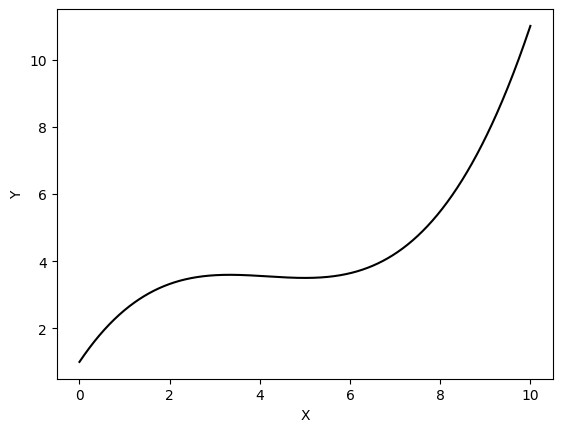

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(0)
A = 1 
B = 2
C = -0.5
D = 0.04
x_true = np.linspace(0, 10, 1000)
y_true = A + B * x_true + C * x_true**2 + D * x_true**3

plt.plot(x_true, y_true, color="black")
plt.xlabel('X')
plt.ylabel('Y')

# Learning from data
The function that you plot above is ofcourse arbitrary, since you chose the coefficients of the polynomial. In fact the choice of a polynomial is also arbitrary (we chose it because it is easy to explain). But in reality this could have a certain meaning; a 1-D function could be a signal from a sensor, for instance a temperature sensor, or it could show how price of a house changes with time, etc. 
(Insert example of a 1-D signal relevant to biology, which is simple like a polynomial)

In reality, you will get only discrete data points from a sensor and you need to build a model from this data. The process of learning the function from a discrete set of points is called Machine Learning. Below, you can see a set of sampled points from the function that you generated above. The sampled points are in red, and the dashed line indicates the true function. 

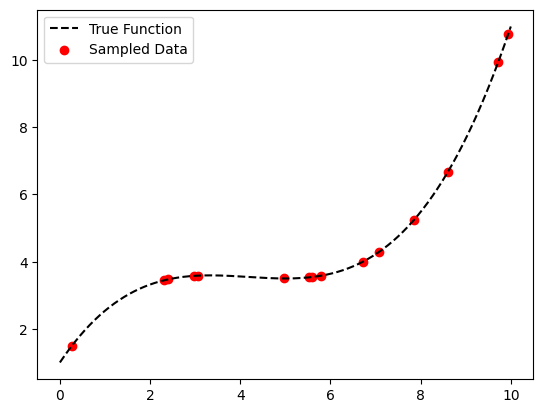

In [2]:
sample_size = 15
sampling_indices = np.random.choice(len(x_true), size=sample_size, replace=False)
x_sample = x_true[sampling_indices]
y_sample = y_true[sampling_indices] 

plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--')
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.legend()

A direct method is ofcourse to use a polynomial function. We will use that method to fit the function first. Then, we will build a neural network from scratch and then fit those same datapoints. We will then discuss what the difference is between fitting a polynomial versus a neural network is. 

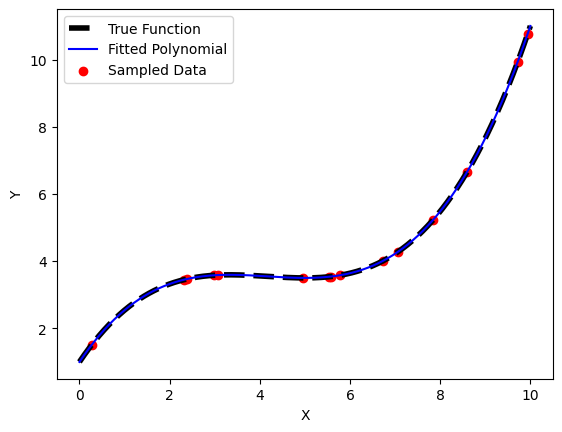

In [3]:
# Fitting a polynomial of degree 3 to the data
coefficients = np.polyfit(x_sample, y_sample, deg=3)
fitted_polynomial = np.poly1d(coefficients)
y_fitted = fitted_polynomial(x_true)
plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=4)
plt.plot(x_true, y_fitted, color="blue", label="Fitted Polynomial")
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()


# Learning through neurons

We will see in this module how the same function can be learnt through a different framework, one loosely inspired by the human brain. A neuron is simply a cell which takes some input and transforms into an output, and the comparison to biological neuron basically ends there. 

For biological neurons, the transformation of the input is generally described as a binary output (either it fires or not). This can be modelled as a sigmoid function, where the output slowly changes between 0 and 1 through an exponential change. 

A digital neuron can ofcourse be modelled by any mathematical function. Normally, this function is a non-linear function. The simplest non-linear function that is typically used is one which just produces a null output for all negative inputs, and returns the same input if it is positive. It is called a rectified linear function (ReLU). Run the code cell below to see the shape of the two functions 

TODO: Add an interactive cell here to show how neurons modify the input given an activation function

In [50]:
import ipywidgets as widgets
# Interactive widget to combine activation functions of three neurons to fit the data. 
# Users choose the weights and biases for each of the three neurons and see how the combined function fits the data.

def combined_activation(w1, b1, w2, b2, w3, b3, w_out1=1.0, w_out2=1.0, w_out3=1.0):
    # Define the activation functions for three neurons
    def neuron1(x):
        return np.maximum(0, w1 * x + b1)  # ReLU activation

    def neuron2(x):
        return np.maximum(0, w2 * x + b2)  # ReLU activation

    def neuron3(x):
        return np.maximum(0, w3 * x + b3)  # ReLU activation

    def output(x):
        # combine with output weights
        return w_out1 * neuron1(x) + w_out2 * neuron2(x) + w_out3 * neuron3(x)
    
    combined_output = output(x_true)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=4)
    plt.plot(x_true, combined_output, color="green", label="Combined Activation", linewidth=2)
    plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Combined Activation of Three Neurons')
    plt.ylim(0, 12)
    plt.legend()
    plt.grid()
    plt.show()
# Create interactive sliders for weights and biases
min_weight = -10
max_weight = 10
min_bias = -10
max_bias = 10
w1_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w1')
b1_slider = widgets.FloatSlider(value=0.0, min=min_bias, max=max_bias, step=0.1, description='b1')
wout1_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w_out1')
w2_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w2')
b2_slider = widgets.FloatSlider(value=0.0, min=min_bias, max=max_bias, step=0.1, description='b2')
wout2_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w_out2')
w3_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w3')
b3_slider = widgets.FloatSlider(value=0.0, min=min_bias, max=max_bias, step=0.1, description='b3')
wout3_slider = widgets.FloatSlider(value=1.0, min=min_weight, max=max_weight, step=0.1, description='w_out3')


# Display the interactive widget
widgets.interact(combined_activation, w1=w1_slider, b1=b1_slider, w2=w2_slider, b2=b2_slider, w3=w3_slider, b3=b3_slider, w_out1=wout1_slider, w_out2=wout2_slider, w_out3=wout3_slider)


interactive(children=(FloatSlider(value=1.0, description='w1', max=10.0, min=-10.0), FloatSlider(value=0.0, de…

<function __main__.combined_activation(w1, b1, w2, b2, w3, b3, w_out1=1.0, w_out2=1.0, w_out3=1.0)>

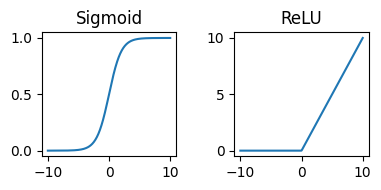

In [5]:
import matplotlib.pyplot as plt
import numpy as np
def activation_function(z, function_type="sigmoid"):
    if function_type == "sigmoid":
        return 1 / (1 + np.exp(-z))
    elif function_type == "relu":
        return np.maximum(0, z)
    else:
        raise ValueError("Unsupported activation function.")
    
def neuron(input, weight, bias, activation_function_type="sigmoid"):
    z = np.dot(input, weight) + bias
    output = activation_function(z, function_type=activation_function_type)
    return output

# plot sigmoid and relu

z = np.linspace(-10, 10, 400)
sigmoid_values = activation_function(z, function_type="sigmoid")
relu_values = activation_function(z, function_type="relu")
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].plot(z, sigmoid_values)
ax[0].set_title("Sigmoid")
ax[1].plot(z, relu_values)
ax[1].set_title("ReLU")
plt.tight_layout()



# Create a layer

The difference between biological neuron and a digital neuron does not end there. The mechanism which guides how the neuron transforms the input signal is governed by complex biochemical reactions in the brain. For modern neural networks, the behaviour of a neuron is governed through a systematic process described below. 

First, the digital neuron (referred as just neuron) is governed by its _weight_ along with the activation function. The weight is a learnable parameter. It is not fixed. Change the weight and activation function of the following neuron to see how it affects the output. 

For a ReLU activation function, the 'slope' is a parameter. Biases are also a learnable parameter to ensure that the outputs are all put to the same scale. The number of learnable parameter for a given neuron changes depending on activation function. 

TO DO: Add interactive to show what happens when we change the weight

In [6]:
# Add an interact to visualise effect of parameters on the neuron output
# Use ReLU, PReLU, sigmoid, and tanh as activation functions
import ipywidgets as widgets
def update_neuron_output(weight, bias):
    input = np.array([1])  # Example input
    # Plot the output
    plt.figure(figsize=(4, 2))
    x_global = np.linspace(-10, 10, 400)
    y_global = x_global * weight 
    y_global[x_global < 0] = 0 
    y_global += bias

    plt.plot(x_global, y_global, label=f"ReLU activation")
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.xlim(-10, 10)
    plt.xticks(np.arange(-10, 11, 5))
    plt.yticks(np.arange(0, 16, 5))
    plt.ylim(-1, 15)
    
    plt.title(f"Weight={weight:.2f}, Bias={bias:.2f}")
    
weight_slider = widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight')
bias_slider = widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Bias')
widgets.interact(update_neuron_output, weight=weight_slider, bias=bias_slider)



interactive(children=(FloatSlider(value=1.0, description='Weight', max=5.0, min=-5.0), FloatSlider(value=0.0, …

<function __main__.update_neuron_output(weight, bias)>

To understand how a neuron "adapts", let us first build a layer of digital neurons (referred as just neurons from now on)

In [7]:
def layer(**neurons):
    layer_output = {}
    for neuron_name, neuron_params in neurons.items():
        input = neuron_params['input']
        weight = neuron_params['weight']
        bias = neuron_params['bias']
        activation_function_type = neuron_params['activation_function_type']
        output = neuron(input, weight, bias, activation_function_type=activation_function_type)
        layer_output[neuron_name] = output
    return layer_output

In [8]:
# Create a layer with 3 neurons
input_vector = np.array([2])
output_vector = np.array([4])
weight_vector = np.array([0.5, -1.5, 1.0])
bias_vector = np.array([0.0, 1.0, -1.0])
activation_function_string = "sigmoid"

layer_output = layer(
    neuron1={
        'input': input_vector,
        'weight': weight_vector[0],
        'bias': bias_vector[0],
        'activation_function_type': activation_function_string
    },
    neuron2={
        'input': input_vector,
        'weight': weight_vector[1],
        'bias': bias_vector[1],
        'activation_function_type': activation_function_string
    },
    neuron3={
        'input': input_vector,
        'weight': weight_vector[2],
        'bias': bias_vector[2],
        'activation_function_type': activation_function_string
    }
)
layer_output

{'neuron1': array([0.73105858]),
 'neuron2': array([0.11920292]),
 'neuron3': array([0.73105858])}

In [9]:
np.asarray(list(layer_output.values()))

array([[0.73105858],
       [0.11920292],
       [0.73105858]])

In [10]:
last_layer_weights = np.array([0.2, -0.4, 0.6])
last_layer_bias = 0.1
final_output = neuron(
    input=np.array(list(layer_output.values())).reshape(-1),
    weight=last_layer_weights,
    bias=last_layer_bias,
    activation_function_type="sigmoid"
)
final_output

0.6541124811672111

In [11]:
# Compute the loss 
def loss_function(predicted, actual, function_type="mse"):
    if function_type == "mse":
        return np.mean((predicted - actual) ** 2)
    elif function_type == "cross_entropy":
        return -np.mean(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))
    else:
        raise ValueError("Unsupported loss function.")

In [12]:
loss_value = loss_function(predicted=final_output, actual=output_vector, function_type="mse")
print("Loss value:", loss_value)

Loss value: 11.194963288681038


# Backpropagation

In [13]:
# Calculate the gradient of the loss with respect to the final output
def loss_gradient(predicted, actual, function_type="mse"):
    if function_type == "mse":
        return 2 * (predicted - actual) / actual.size
    elif function_type == "cross_entropy":
        return -(actual / predicted) + ((1 - actual) / (1 - predicted))
    else:
        raise ValueError("Unsupported loss function.")
gradient_value = loss_gradient(predicted=final_output, actual=output_vector, function_type="mse")
print("Gradient value:", gradient_value)

Gradient value: [-6.69177504]


In [30]:
# Update the weights and biases using gradient descent
learning_rate = 0.01
updated_weights = last_layer_weights - learning_rate * gradient_value * np.array(list(layer_output.values())).reshape(-1)
updated_bias = last_layer_bias - learning_rate * gradient_value
print("Updated weights:", updated_weights)
print("Updated bias:", updated_bias)


Updated weights: [ 0.2489208  -0.39202321  0.6489208 ]
Updated bias: [0.16691775]


In [31]:
# Show the updated output after one step of gradient descent
updated_final_output = neuron(
    input=np.array(list(layer_output.values())).reshape(-1),
    weight=updated_weights,
    bias=updated_bias,
    activation_function_type="sigmoid"
)
print("Updated final output:", updated_final_output)



Updated final output: [0.68493872]


In [32]:
# Updated loss after one step of gradient descent
updated_loss_value = loss_function(predicted=updated_final_output, actual=output_vector, function_type="mse")
print("Updated Loss value:", updated_loss_value)
print("Original Loss value:", loss_value)
print("Loss reduction:", loss_value - updated_loss_value)

Updated Loss value: 10.989631260244353
Original Loss value: 11.194963288681038
Loss reduction: 0.2053320284366844


Text(0.5, 1.0, 'Effect of Learning Rate on Loss')

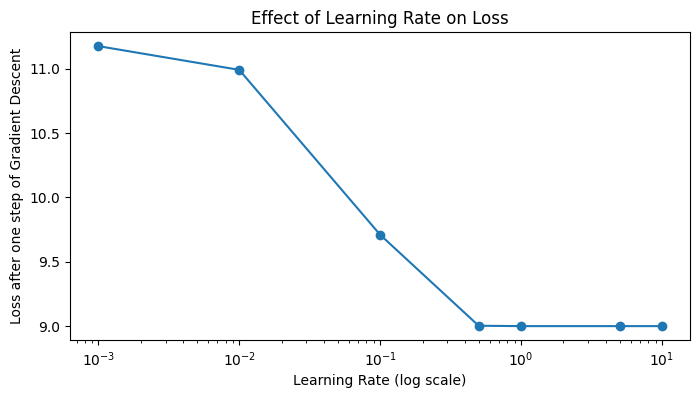

In [36]:
learning_rate_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10]
loss_for_learning_rates = []

# What was the loss for each learning rate after one step of gradient descent?
for lr in learning_rate_values:
    updated_weights = last_layer_weights - lr * gradient_value * np.array(list(layer_output.values())).reshape(-1)
    updated_bias = last_layer_bias - lr * gradient_value
    updated_final_output = neuron(
        input=np.array(list(layer_output.values())).reshape(-1),
        weight=updated_weights,
        bias=updated_bias,
        activation_function_type="sigmoid"
    )
    updated_loss = loss_function(predicted=updated_final_output, actual=output_vector, function_type="mse")
    loss_for_learning_rates.append(updated_loss)

plt.figure(figsize=(8, 4))
plt.plot(learning_rate_values, loss_for_learning_rates, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Loss after one step of Gradient Descent')
plt.title('Effect of Learning Rate on Loss')
